In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('../Data/HRDataset_v14.csv')
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [33]:
df['DateofTermination'] = pd.to_datetime(df['DateofTermination'], errors='coerce')
df['DateofHire'] = pd.to_datetime(df['DateofHire'], errors='coerce')
df['Tenure_Days'] = (df['DateofTermination'].fillna(pd.Timestamp.now()) - df['DateofHire']).dt.days
df['DateofTermination'] = pd.to_datetime(df['DateofTermination'], format='%m/%d/%y', errors='coerce')
df['DateofHire'] = pd.to_datetime(df['DateofHire'], format='%m/%d/%y', errors='coerce')

# Salaries and engagement

In [4]:
df[['Salary', 'EngagementSurvey']].corr()

,Salary,EngagementSurvey
Salary,1.000000,0.064966
EngagementSurvey,0.064966,1.000000


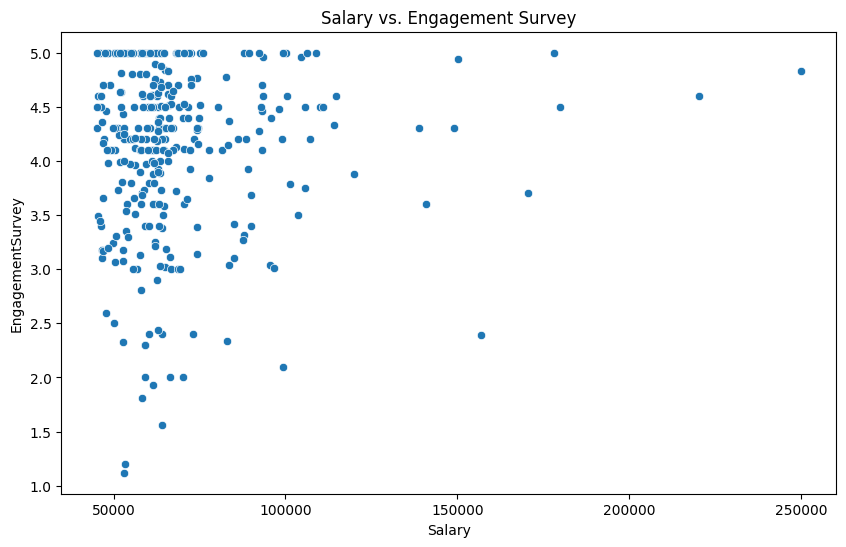

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Salary', y='EngagementSurvey')
plt.title('Salary vs. Engagement Survey')
plt.show()

In [6]:
df.groupby('Department')[['Salary', 'EngagementSurvey']].corr().iloc[0::2,-1]

Department                  
Admin Offices         Salary    0.466802
Executive Office      Salary         NaN
IT/IS                 Salary    0.104595
Production            Salary   -0.026000
Sales                 Salary    0.171564
Software Engineering  Salary    0.112274
Name: EngagementSurvey, dtype: float64

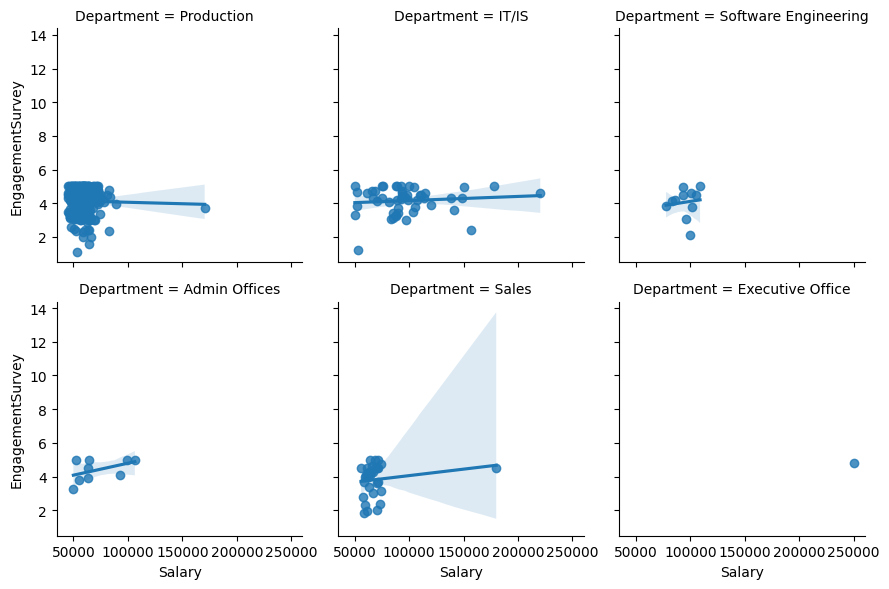

In [7]:
sns.lmplot(data=df, x='Salary', y='EngagementSurvey', col='Department', col_wrap=3, height=3)

Department                  
Admin Offices         Salary    0.150050
Executive Office      Salary         NaN
IT/IS                 Salary    0.222983
Production            Salary   -0.035738
Sales                 Salary    0.135236
Software Engineering  Salary    0.588856
Name: EmpSatisfaction, dtype: float64

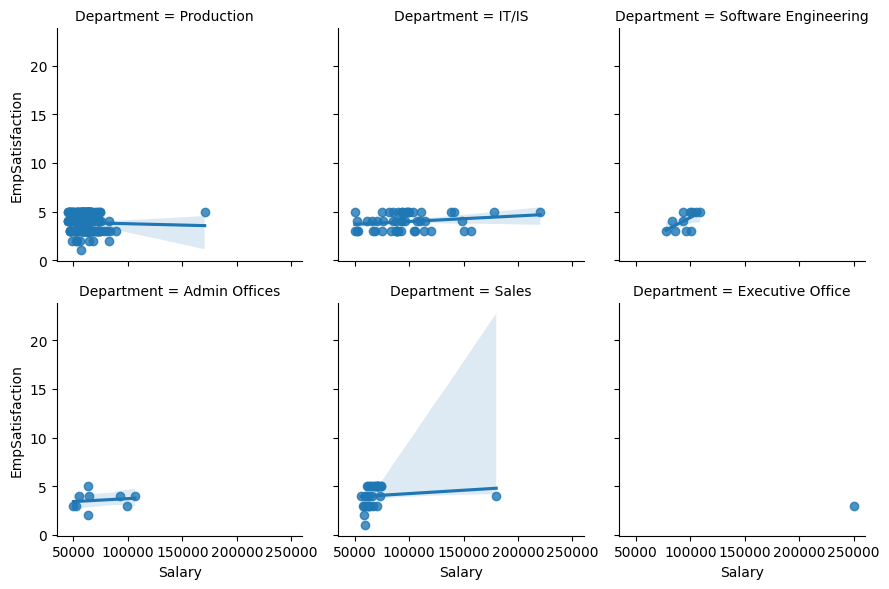

In [18]:
sns.lmplot(data=df, x='Salary', y='EmpSatisfaction', col='Department', col_wrap=3, height=3)
df.groupby('Department')[['Salary', 'EmpSatisfaction']].corr().iloc[0::2,-1]

# Salaries

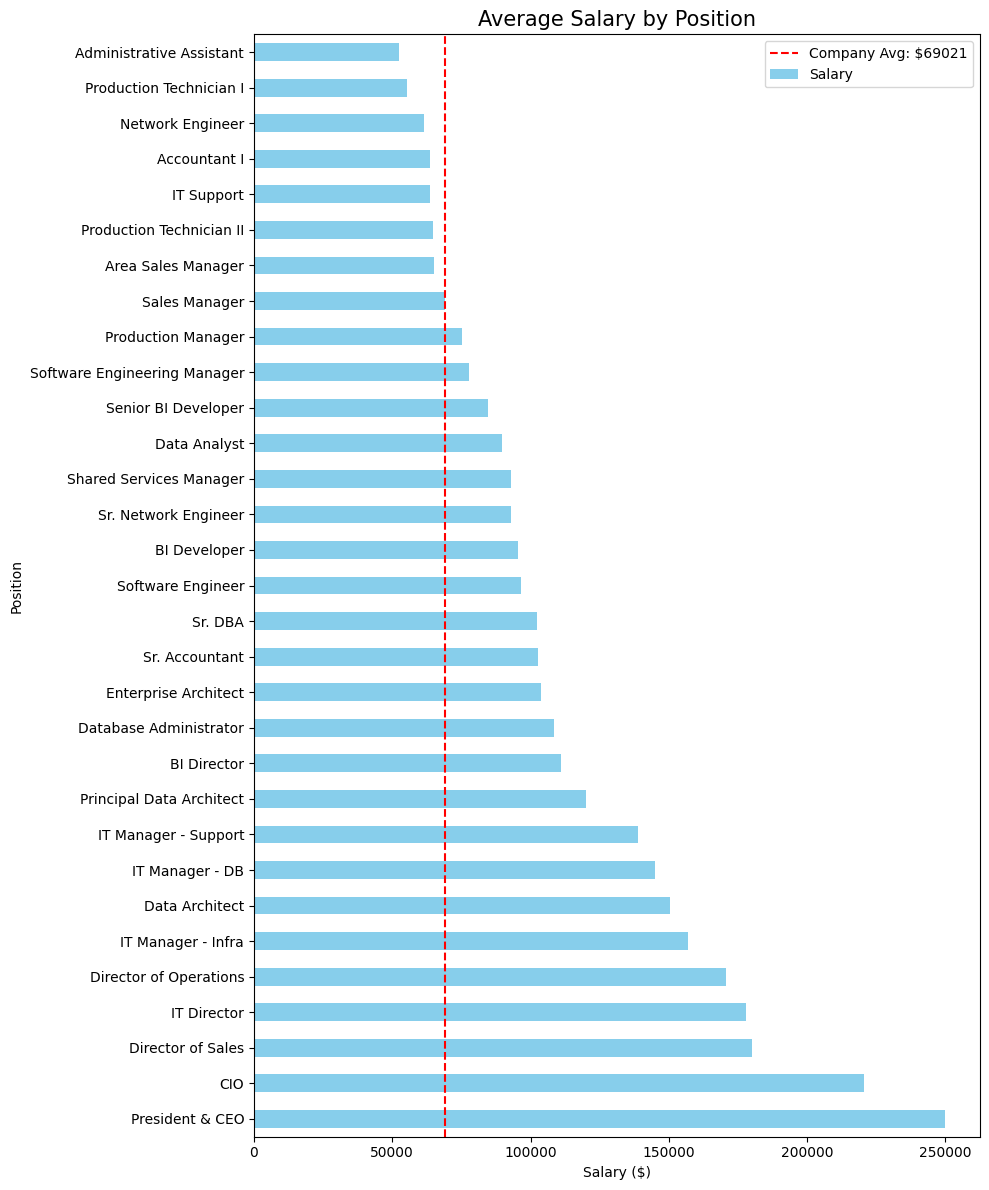

In [13]:
df['Position'] = df['Position'].str.strip()
salary_by_pos_mean = df.groupby('Position')['Salary'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 12))
salary_by_pos_mean.plot(kind='barh', color='skyblue')
plt.axvline(df['Salary'].mean(), color='red', linestyle='--', label=f"Company Avg: ${df['Salary'].mean():.0f}")
plt.title('Average Salary by Position', fontsize=15)
plt.xlabel('Salary ($)')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

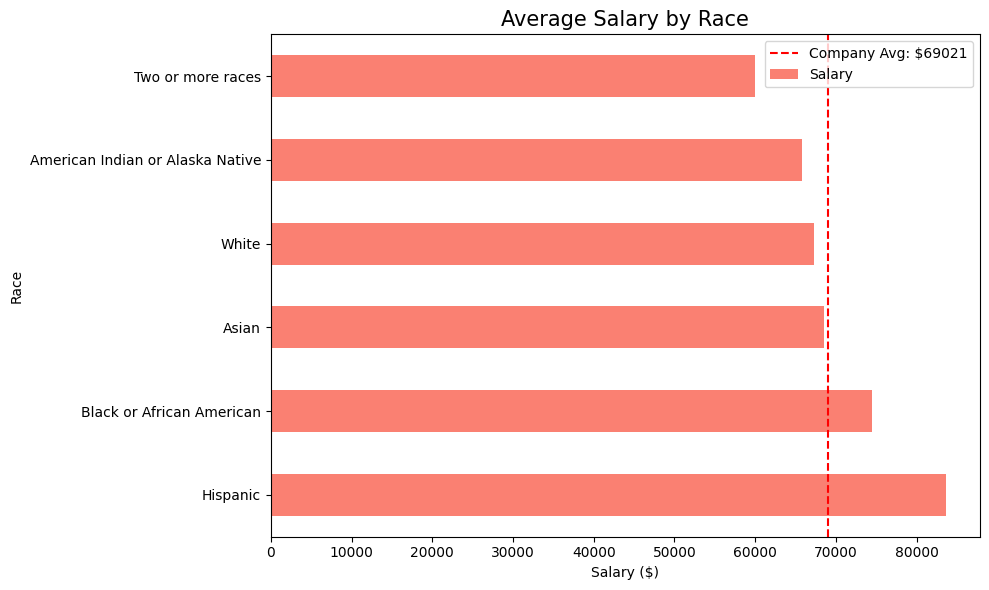

In [19]:
salary_by_race = df.groupby('RaceDesc')['Salary'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
salary_by_race.plot(kind='barh', color='salmon')
plt.axvline(df['Salary'].mean(), color='red', linestyle='--', label=f"Company Avg: ${df['Salary'].mean():.0f}")
plt.title('Average Salary by Race', fontsize=15)
plt.xlabel('Salary ($)')
plt.ylabel('Race')
plt.legend()
plt.tight_layout()
plt.show()

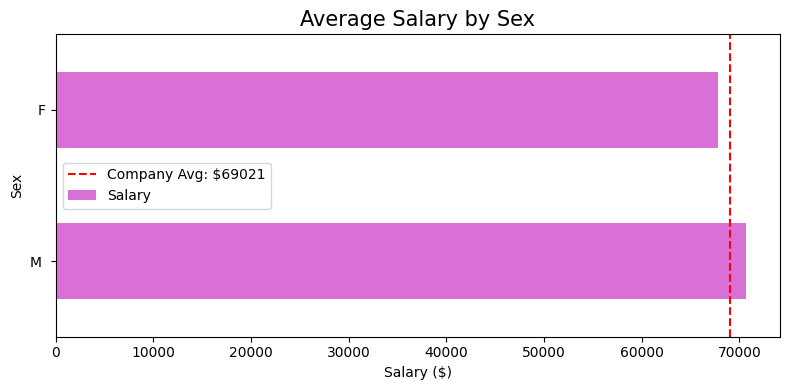

In [20]:
salary_by_sex = df.groupby('Sex')['Salary'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
salary_by_sex.plot(kind='barh', color='orchid')
plt.axvline(df['Salary'].mean(), color='red', linestyle='--', label=f"Company Avg: ${df['Salary'].mean():.0f}")
plt.title('Average Salary by Sex', fontsize=15)
plt.xlabel('Salary ($)')
plt.ylabel('Sex')
plt.legend()
plt.tight_layout()
plt.show()

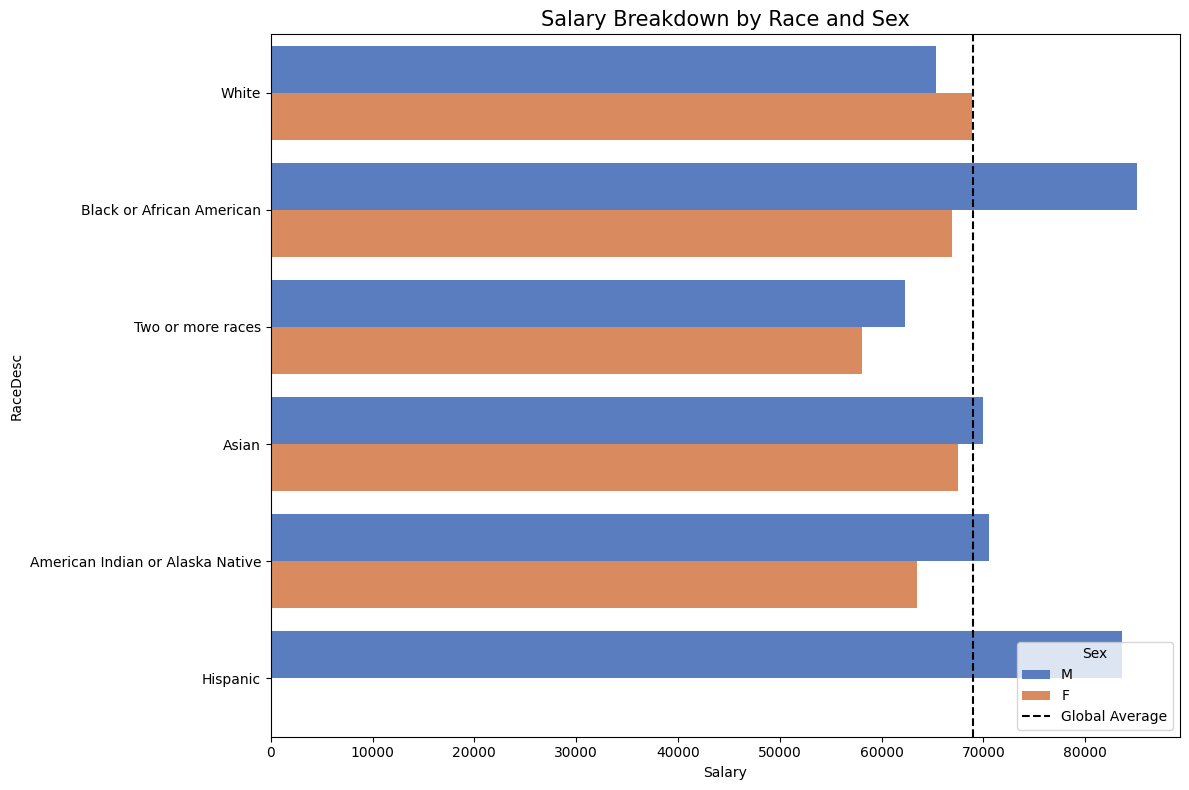

In [22]:
plt.figure(figsize=(12, 8))
sns.barplot(data=df, x='Salary', y='RaceDesc', hue='Sex', estimator=np.mean, errorbar=None, palette='muted')

plt.axvline(df['Salary'].mean(), color='black', linestyle='--', label='Global Average')
plt.title('Salary Breakdown by Race and Sex', fontsize=15)
plt.legend(title='Sex', loc='lower right')
plt.tight_layout()
plt.show()

In [24]:
combined_summary = df.groupby(['RaceDesc', 'Sex'])['Salary'].agg(['count', 'mean', 'median'])
combined_summary = combined_summary.sort_values(['RaceDesc', 'mean'], ascending=[True, False]).round(2)
print("\nDetailed Salary Summary (Race & Sex):")
print(combined_summary)


Detailed Salary Summary (Race & Sex):
                                      count      mean   median
RaceDesc                         Sex                          
American Indian or Alaska Native M        1  70545.00  70545.0
                                 F        2  63436.50  63436.5
Asian                            M       12  69939.42  64731.0
                                 F       17  67520.12  63676.0
Black or African American        M       33  85066.12  71339.0
                                 F       47  66963.83  61584.0
Hispanic                         M        1  83667.00  83667.0
Two or more races                M        5  62313.80  61568.0
                                 F        6  58068.50  57837.0
White                            F      104  68846.52  62405.0
                                 M       83  65334.13  61809.0


# Statistical testing for discrimination

In [29]:
relevant_races = ['White', 'Black or African American']
results = []

for race in relevant_races:
    males = df[(df['RaceDesc'] == race) & (df['Sex'].str.strip() == 'M')]['Salary'].dropna()
    females = df[(df['RaceDesc'] == race) & (df['Sex'].str.strip() == 'F')]['Salary'].dropna()
    
    if len(males) > 1 and len(females) > 1:
        t_stat, p_val = stats.ttest_ind(males, females)
        results.append({
            'Race': race,
            'Male_Mean': males.mean(),
            'Female_Mean': females.mean(),
            'P-Value': p_val,
            'Significant': p_val < 0.05
        })
    else:
        results.append({
            'Race': race,
            'Male_Mean': males.mean() if not males.empty else 0,
            'Female_Mean': females.mean() if not females.empty else 0,
            'P-Value': "Insufficient Data",
            'Significant': False
        })

results_df = pd.DataFrame(results)
results_df

,Race,Male_Mean,Female_Mean,P-Value,Significant
0,White,65334.132530,68846.519231,0.338768,False
1,Black or African American,85066.121212,66963.829787,0.005606,True


In [30]:
u_stat, p_val_u = stats.mannwhitneyu(males, females)
print(f"Mann-Whitney P-Value: {p_val_u:.4f}")

Mann-Whitney P-Value: 0.0222


In [31]:
target_pos = 'Production Technician I'
race_filter = 'Black or African American'

sub_df = df[(df['RaceDesc'] == race_filter) & (df['Position'] == target_pos)]

summary = sub_df.groupby('Sex')['Salary'].agg(['count', 'mean', 'median'])
print(f"Comparison for {target_pos} ({race_filter} only):")
print(summary)

Comparison for Production Technician I (Black or African American only):
     count      mean   median
Sex                          
F       20  56517.65  56243.0
M       10  52820.20  52953.0


In [34]:
tenure_check = df[(df['RaceDesc'] == 'Black or African American') & 
                  (df['Position'] == 'Production Technician I')].groupby('Sex')['Tenure_Days'].mean()
print(tenure_check)

Sex
F     3642.3
M     2855.6
Name: Tenure_Days, dtype: float64
